In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import time
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models

In [ ]:
dataset_path = "/content/drive/MyDrive/Retinopathy"

data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224,224),
    batch_size=32,
    label_mode="int",
    shuffle=True
)

Found 3662 files belonging to 5 classes.


In [ ]:
#Splitting the data into train/validation/test blocks
total_size = len(data)

train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)

train_data = data.take(train_size)
temp_data = data.skip(train_size)

val_data = temp_data.take(val_size)
test_data = temp_data.skip(val_size)

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.applications.resnet import preprocess_input as res_pre

def hybrid_preprocess(x, y):
    x = tf.cast(x, tf.float32)

    # Apply both preprocessings and average
    x1 = eff_pre(x)
    x2 = res_pre(x)

    x = (x1 + x2) / 2.0
    return x, y

train_data = train_data.map(hybrid_preprocess).prefetch(tf.data.AUTOTUNE)
val_data = val_data.map(hybrid_preprocess).prefetch(tf.data.AUTOTUNE)
test_data = test_data.map(hybrid_preprocess).prefetch(tf.data.AUTOTUNE)

In [ ]:
from collections import Counter
import os

dataset_path = "/content/drive/MyDrive/Retinopathy"

class_counts = {}

for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_folder):
        class_counts[class_name] = len(os.listdir(class_folder))

print("Class Counts:", class_counts)

total_samples = sum(class_counts.values())
num_classes = len(class_counts)

class_weights = {}

for i, class_name in enumerate(class_counts):
    class_weights[i] = total_samples / (num_classes * class_counts[class_name])

print("Class Weights:", class_weights)

Class Counts: {'Proliferate_DR': 295, 'Severe': 193, 'No_DR': 1805, 'Moderate': 999, 'Mild': 370}
Class Weights: {0: 2.4827118644067796, 1: 3.7948186528497407, 2: 0.4057617728531856, 3: 0.7331331331331331, 4: 1.9794594594594594}


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

In [ ]:
# EfficientNet branch
eff_base = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# ResNet branch
res_base = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze most layers (anti-overfitting)
for layer in eff_base.layers[:-40]:
    layer.trainable = False

for layer in res_base.layers[:-40]:
    layer.trainable = False

# Input
inputs = tf.keras.Input(shape=(224,224,3))

# Pass through both models
eff_features = eff_base(inputs)
res_features = res_base(inputs)

# Global pooling
eff_features = layers.GlobalAveragePooling2D()(eff_features)
res_features = layers.GlobalAveragePooling2D()(res_features)

# 🔥 Feature fusion
x = layers.concatenate([eff_features, res_features])

# Dense layers
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

# 🔥 Attention
attention = layers.Dense(512, activation='sigmoid')(x)
x = layers.multiply([x, attention])

# Further layers
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(5, activation='softmax')(x)

# Build model
model = models.Model(inputs=inputs, outputs=outputs)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_2[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input_layer_2[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3328)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,704,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    262,656 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 512)       │          0 │ dropout[0][0],    │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │      1,285 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 29,739,048 (113.45 MB)

 Trainable params: 19,983,253 (76.23 MB)

 Non-trainable params: 9,755,795 (37.22 MB)

In [ ]:
start_time = time.time()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop],
    class_weight=class_weights
)

end_time = time.time()

print("Training Time:", end_time - start_time)

Epoch 1/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 362s 4s/step - accuracy: 0.5641 - loss: 1.7562 - val_accuracy: 0.7463 - val_loss: 0.8293
Epoch 2/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 550ms/step - accuracy: 0.7137 - loss: 1.2540 - val_accuracy: 0.7996 - val_loss: 0.5933
Epoch 3/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 489ms/step - accuracy: 0.7477 - loss: 1.0450 - val_accuracy: 0.7960 - val_loss: 0.6586
Epoch 4/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 32s 400ms/step - accuracy: 0.7918 - loss: 0.8619 - val_accuracy: 0.7978 - val_loss: 0.6318
Epoch 5/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 33s 412ms/step - accuracy: 0.8238 - loss: 0.6862 - val_accuracy: 0.8107 - val_loss: 0.6091
Epoch 6/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 32s 397ms/step - accuracy: 0.8488 - loss: 0.5702 - val_accuracy: 0.7684 - val_loss: 1.0200
Epoch 7/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 378ms/step - accuracy: 0.8836 - loss: 0.4363 - val_accuracy: 0.8456 - val_loss: 0.6061
Epoch 8/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 32s 398ms/step - accuracy: 0.8992 - loss: 0.3526 - val_accura

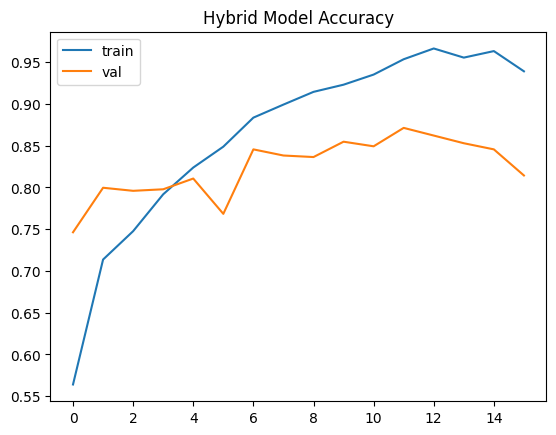

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Hybrid Model Accuracy")
plt.show()

In [ ]:
best_epoch = np.argmax(history.history['val_accuracy'])

train_acc = history.history['accuracy'][best_epoch]
val_acc = history.history['val_accuracy'][best_epoch]


test_loss, test_acc = model.evaluate(test_data)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 168ms/step - accuracy: 0.8136 - loss: 0.5962
Training Accuracy: 0.9535
Validation Accuracy : 0.8713
Test Accuracy: 0.8136


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


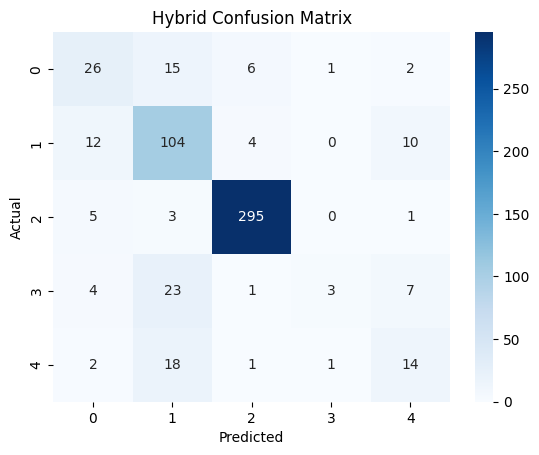

              precision    recall  f1-score   support

           0       0.53      0.52      0.53        50
           1       0.64      0.80      0.71       130
           2       0.96      0.97      0.97       304
           3       0.60      0.08      0.14        38
           4       0.41      0.39      0.40        36

    accuracy                           0.79       558
   macro avg       0.63      0.55      0.55       558
weighted avg       0.79      0.79      0.77       558



In [ ]:
y_true = []
y_pred = []

for images, labels in test_data:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Hybrid Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_true, y_pred))